# Кейс 3. Прогнозирование конверсии пользователя в первую подписку из пробного периода

**Компания:** онлайн-кинотеатр, предоставляющий доступ к библиотеке фильмов, сериалов и собственного контента по модели ежемесячной подписки.

**Продукт:** мобильное и веб-приложение, где пользователи оформляют подписку и получают доступ к контенту. Задача решается в рамках маркетингово-аналитической платформы компании, чтобы повысить удержание пользователей и снизить отток.

**Проблема продукта:** Не все пользователи покупают подписку после окончания пробного периода. Это приводит к росту расходов на привлечение новых пользователей.

# Case 3. Predicting User Conversion to a First Subscription After a Trial Period

**Company:** An online streaming service providing access to a library of movies, series, and original content through a monthly subscription model.

**Product:** A mobile and web application where users sign up for a subscription and gain access to content. The task is addressed within the company's marketing-analytical platform to improve user retention and reduce churn.

**Product Problem:** Not all users purchase a subscription after their trial period ends. This leads to increased customer acquisition costs.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.stats import chi2_contingency
print('все ОК!')

все ОК!


In [2]:
# записываем csv в переменную data в виде таблицы
data = pd.read_csv('videostreaming_platform.csv')

# показываем первые 5 строк
data.head()

,user_id,start_trial_date,city,device,source,favourite_genre,avg_min_watch_daily,number_of_days_logged,churn
0,d1b6ef34-1991-452a-8c39-c83c0d5805fe,2024-02-01,St Petersburg,ios,performance,drama,2.076642,4,1
1,f1bf2396-73d8-461e-a775-9f068bd99326,2024-02-01,Other,web,seo,criminal,5.101392,1,1
2,ec9fa0be-4bd8-4fe6-910a-e9e6d4bbba28,2024-02-01,Ufa,web,performance,criminal,2.906597,1,1
3,b0195e96-af2e-4ac3-8f60-26b8d862af84,2024-02-01,Moscow,smarttv,seo,thriller,2.702388,6,0
4,a208985a-7244-4291-8d38-64c8141e27b2,2024-02-01,Ufa,web,performance,thriller,10.237305,1,1


In [3]:
# смоторим на описательные статистики
print(data.describe())

# пытаемся анализировать
print()
print('Смущает минимальное время в 0.000181 по столбцу avg_min_watch_daily - это явно ошибка.\nВ среднем у пользователя уходит 7,8 (пусть будет минут) на просмотр.\n80 минут смотреть тоже реально.\nВозможно, очень много значений сконцентрировано около нуля - эмпирически пользователь не может смотреть видео 0.25 минуты, и зайти и выйти тоже.\nОт таких данных надо избавляться - но мы обязательно применим статистический подход.')
print(f'Строк с нереальным временем просмотра: {(data['avg_min_watch_daily'] <= 0.25).sum()}, это {(data['avg_min_watch_daily'] <= 0.25).sum() / (data['avg_min_watch_daily']).sum()}% от данных.')

print()

rows, cols = data.shape
print(f'Количество строк: {rows}, количество столбцов: {cols}')

print()

# проверям типы данных - есть ли ошибки
print(data.dtypes)

print()

# обнаружили тип данных обджект у столбца с датой
print('Колонка start_trial_date записана в текстовом виде, сменим тип данных!')
data['start_trial_date'] = pd.to_datetime(data['start_trial_date'])
print('Проверяем:')
print(f'Теперь тип данных такой: {data['start_trial_date'].dtype}')

print()

# ищем дубли и пропуски в данных (по каждому столбцу):
print('Дубликатов нет, каждая строка - уникальный пользователь.' if data['user_id'].nunique() == data['user_id'].count() else 'Есть дубли!')

print()

for col in data.columns:
    missing_col = data[col].isnull().sum()
    if missing_col > 0:
        print(f'В столбце {col} {missing_col} пропусков.')

       avg_min_watch_daily  number_of_days_logged         churn
count         28000.000000            28000.00000  28000.000000
mean              7.812663                1.88600      0.789286
std               7.739760                1.48293      0.407823
min               0.000181                1.00000      0.000000
25%               2.521966                1.00000      1.000000
50%               5.419012                1.00000      1.000000
75%              10.487946                2.00000      1.000000
max              80.072401                7.00000      1.000000

Смущает минимальное время в 0.000181 по столбцу avg_min_watch_daily - это явно ошибка.
В среднем у пользователя уходит 7,8 (пусть будет минут) на просмотр.
80 минут смотреть тоже реально.
Возможно, очень много значений сконцентрировано около нуля - эмпирически пользователь не может смотреть видео 0.25 минуты, и зайти и выйти тоже.
От таких данных надо избавляться - но мы обязательно применим статистический подход.
Строк

# Ключевые выводы на первичном этапе:

Смущает минимальное время в 0.000181 по столбцу avg_min_watch_daily - это явно ошибка.

В среднем у пользователя уходит 7,8 (пусть будет минут) на просмотр.

80 минут смотреть тоже реально.

Возможно, очень много значений сконцентрировано около нуля - эмпирически пользователь не может смотреть видео 0.25 минуты, и зайти и выйти тоже.

От таких данных надо избавляться - но перед этим мы обязательно применим статистический подход.

Строк с нереальным временем просмотра: 817, это 0.0037347792868167007% от данных.

Дубликатов нет.

В столбце city 308 пропусков - не критично.

В столбце favourite_genre 7952 пропусков - мы не знаем любимый жанр 28,4% пользователей, это много.

В целом хороший датасет! Будем работать!

# Key Findings at the Initial Stage:

The minimum value of 0.000181 in the avg_min_watch_daily column is concerning—clearly an error.

On average, a user spends 7.8 (let's assume minutes) watching.

80 minutes of watching is also realistic.

There may be many values concentrated around zero—empirically, a user cannot watch a video for 0.25 minutes, and simply opening and closing the app also doesn't justify this.

Such data should be removed—but before that, we will definitely apply a statistical approach.

Rows with unrealistic watch time: 817, which is 0.0037347792868167007% of the data.

No duplicates.

In the city column, there are 308 missing values—not critical.

In the favourite_genre column, there are 7,952 missing values—we don't know the favorite genre for 28.4% of users, which is a lot.

Overall, a good dataset! Let's proceed!

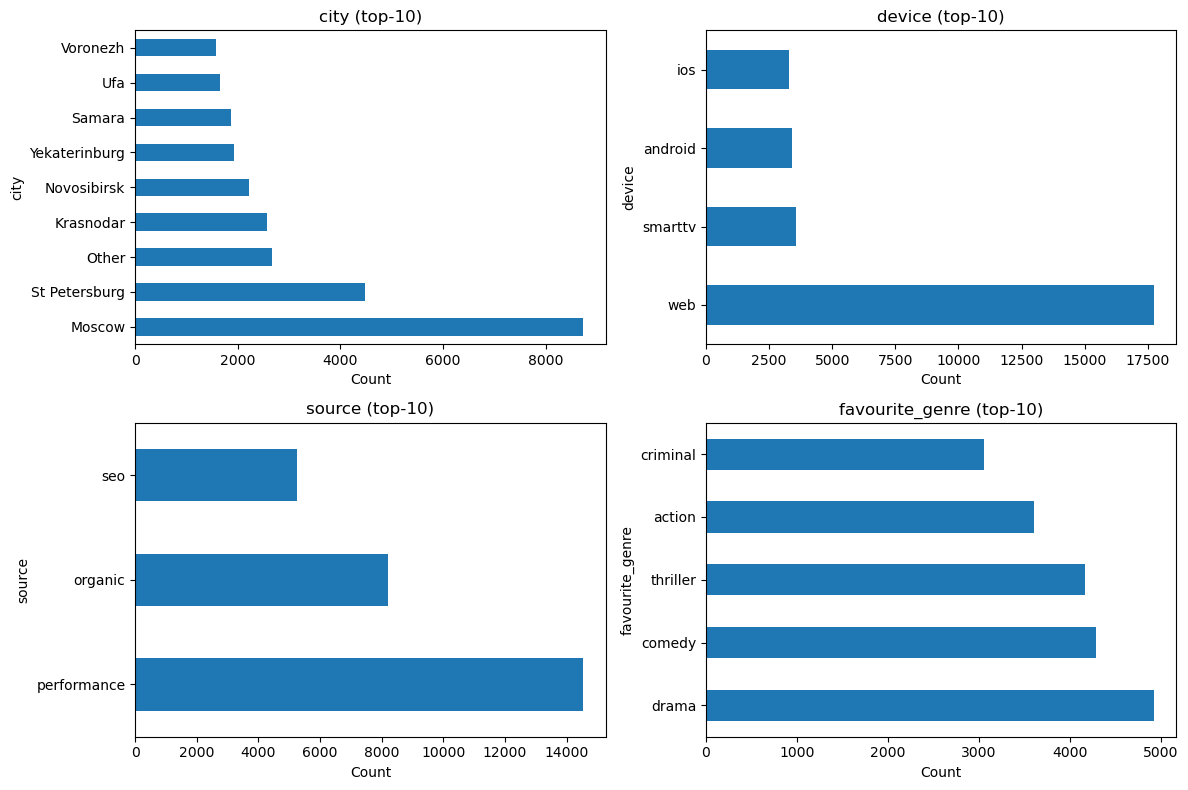

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, ['city', 'device', 'source', 'favourite_genre']):
    if col in data.columns:
        data[col].value_counts().head(10).plot(kind='barh', ax=ax)
        ax.set_title(f'{col} (top-10)')
        ax.set_xlabel('Count')

plt.tight_layout()
plt.show()

In [5]:
for col in ['city', 'device', 'source', 'favourite_genre']:
    if col in data.columns:
        print(f"Столбец: {col}")
        print(f"Всего уникальных значений: {data[col].nunique()}")
        print(data[col].value_counts(dropna=False))
        print()

Столбец: city
Всего уникальных значений: 9
city
Moscow           8736
St Petersburg    4480
Other            2660
Krasnodar        2575
Novosibirsk      2213
Yekaterinburg    1932
Samara           1876
Ufa              1652
Voronezh         1568
NaN               308
Name: count, dtype: int64

Столбец: device
Всего уникальных значений: 4
device
web        17752
smarttv     3556
android     3416
ios         3276
Name: count, dtype: int64

Столбец: source
Всего уникальных значений: 3
source
performance    14540
organic         8204
seo             5256
Name: count, dtype: int64

Столбец: favourite_genre
Всего уникальных значений: 5
favourite_genre
NaN         7952
drama       4928
comedy      4284
thriller    4172
action      3612
criminal    3052
Name: count, dtype: int64



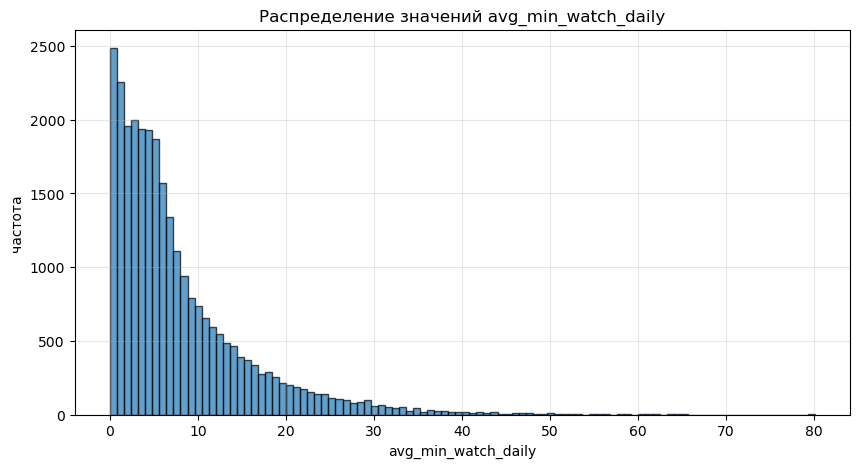

Распределение похоже на геометрическое!
При этом распределение сосредоточено около 5 минут...


In [6]:
# смотрим на распределение avg_min_watch_daily
plt.figure(figsize=(10, 5))
plt.hist(data['avg_min_watch_daily'], bins=100, alpha=0.7, edgecolor='black')
plt.title('Распределение значений avg_min_watch_daily')
plt.xlabel('avg_min_watch_daily')
plt.ylabel('частота')
plt.grid(True, alpha=0.3)
plt.show()

print('Распределение похоже на геометрическое!\nПри этом распределение сосредоточено около 5 минут...')

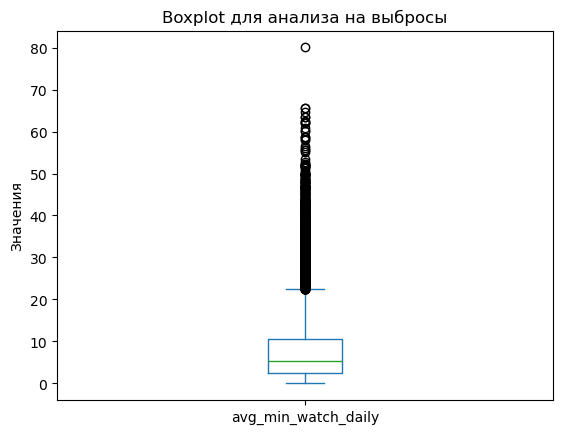

Видим ОЧЕНЬ много выбросов!
Но вдруг выбросы - это наша целевая аудитория, и чем больше времени человек проводит времени в приложении, тем явнее он - НАШ КЛИЕНТ???


In [7]:
# строим Boxplot
data['avg_min_watch_daily'].plot(kind='box')
plt.title('Boxplot для анализа на выбросы')
plt.ylabel('Значения')
plt.show()
print('Видим ОЧЕНЬ много выбросов!\nНо вдруг выбросы - это наша целевая аудитория, и чем больше времени человек проводит времени в приложении, тем явнее он - НАШ КЛИЕНТ???')

In [8]:
# определяем границы выбросов по IQR
Q1 = data['avg_min_watch_daily'].quantile(0.25)
Q3 = data['avg_min_watch_daily'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = max(0, Q1 - 1.5 * IQR)
upper_bound = Q3 + 1.5 * IQR

# разделяем на группы
data['is_outlier'] = (data['avg_min_watch_daily'] < lower_bound) | (data['avg_min_watch_daily'] > upper_bound)
data['outlier_type'] = 'normal'
data.loc[data['avg_min_watch_daily'] < lower_bound, 'outlier_type'] = 'low_outlier'
data.loc[data['avg_min_watch_daily'] > upper_bound, 'outlier_type'] = 'high_outlier'

print("РАСПРЕДЕЛЕНИЕ ПО ГРУППАМ:")
print(data['outlier_type'].value_counts())
print(f"\nГраницы выбросов: [{lower_bound:.2f}, {upper_bound:.2f}] мин")

РАСПРЕДЕЛЕНИЕ ПО ГРУППАМ:
outlier_type
normal          26376
high_outlier     1624
Name: count, dtype: int64

Границы выбросов: [0.00, 22.44] мин



КОНВЕРСИЯ ПО ГРУППАМ:
              count  pct_of_total    sum  conversion_rate
outlier_type                                             
high_outlier   1624           5.8    485        29.864532
normal        26376          94.2  21615        81.949500


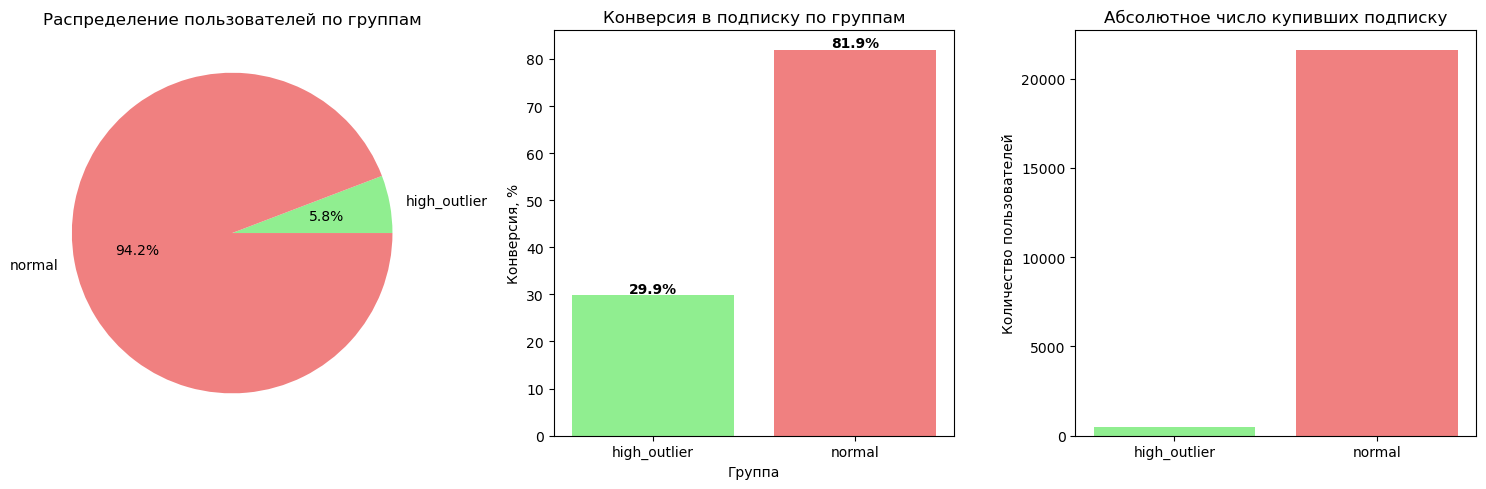

In [9]:
# конверсия по группам
conversion_by_group = data.groupby('outlier_type')['churn'].agg(['count', 'mean', 'sum'])
conversion_by_group['conversion_rate'] = conversion_by_group['mean'] * 100
conversion_by_group['pct_of_total'] = conversion_by_group['count'] / len(data) * 100

print("\nКОНВЕРСИЯ ПО ГРУППАМ:")
print(conversion_by_group[['count', 'pct_of_total', 'sum', 'conversion_rate']])

# визуализация
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. распределение групп
axes[0].pie(conversion_by_group['count'], 
           labels=conversion_by_group.index, 
           autopct='%1.1f%%',
           colors=['lightgreen', 'lightcoral', 'lightblue'])
axes[0].set_title('Распределение пользователей по группам')

# 2. конверсия по группам
groups = conversion_by_group.index
conversion_rates = conversion_by_group['conversion_rate']

bars = axes[1].bar(groups, conversion_rates, 
                  color=['lightgreen', 'lightcoral', 'lightblue'])
axes[1].set_title('Конверсия в подписку по группам')
axes[1].set_ylabel('Конверсия, %')
axes[1].set_xlabel('Группа')

# добавляем значения на столбцы
for bar, rate in zip(bars, conversion_rates):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{rate:.1f}%', ha='center', fontweight='bold')

# 3. абсолютное количество конверсий
axes[2].bar(groups, conversion_by_group['sum'],
           color=['lightgreen', 'lightcoral', 'lightblue'])
axes[2].set_title('Абсолютное число купивших подписку')
axes[2].set_ylabel('Количество пользователей')

plt.tight_layout()
plt.show()

# Некоторые выводы после визуального осмотра: 

Сразу обратим внимание на два признака - city и favourite_genre.

Там есть NaN значения.

Порадовало, что нет багов и слов, которых не должно быть в признаках.

Так как оба признака, в которых они есть, категориальные, значит, надо заполнить пропуска модой распределения - в обоих случаях она будет одна - Moscow и drama.

После чего необходимо удалить выбросы - лучше для этого использовать IQR - эта методология работает с любым распределением, в том числе и с геометрическим, как у нас выше, так как квантили не зависят от формы распределения, экстремальных значений и симметрии данных.

Z-стандартизация, к примеру, требует нормального (симметричного) распределения, так как при ее расчете используется среднее и стандартное отклонение (а их значения искажает любое распределение, отличное от нормального).

Но, СТОП!

А давай перед удалением проверим - вдруг пользователи, которые много времени проводят в нашем приложении - это и есть наша ЦА - для этого строим графики.

**Видим, что люди, которые много времени проводят в нашем приложении - ХУЖЕ конвертируются в подписку!**

Это ключевой инстайт - из этого вытекает одна из гипотез.

# Some Conclusions After Visual Inspection:

Let's immediately focus on two features: city and favourite_genre.

There are NaN values in both.

It's reassuring that there are no bugs or unexpected words in the feature values.

Since both are categorical features where missing values occur, we should fill the missing values with the mode of the distribution. In both cases, the mode will be single: "Moscow" for city and "drama" for favourite_genre.

After this, it is necessary to remove outliers—it is better to use IQR for this purpose. This methodology works with any distribution, including geometric distributions like ours above, because quantiles are independent of the distribution shape, extreme values, and data symmetry.

Z‑standardization, for example, requires a normal (symmetric) distribution, since its calculation uses the mean and standard deviation—values that are distorted by any distribution other than normal.

WAIT!

But let's check before removing them - what if users who spend a lot of time in our app ARE actually our target audience? For this, we build graphs.

**We see that people who spend a lot of time in our app convert WORSE into subscriptions!**

This is a key insight - from this follows one of the hypotheses.

In [10]:
# заменяем пропуски в city на моду распределения
city_mode = data['city'].mode()
data.loc[data['city'].isna(), 'city'] = city_mode.iloc[0]

# заменяем пропуски в fovourite_genre
favourite_genre_mode = data['favourite_genre'].mode()
data.loc[data['favourite_genre'].isna(), 'favourite_genre'] = favourite_genre_mode.iloc[0]

# проверяем на NaN
print(f'Пропусков в city: {(data['city'].isna()).sum()}')
print(f'Пропусков в favourite_genre: {(data['favourite_genre'].isna()).sum()}')

Пропусков в city: 0
Пропусков в favourite_genre: 0


In [11]:
# найдем % пользователей, которые купили подписку
all_units = len(data)
users_churn_0 = (data['churn'] == 0).sum()
users_churn_1 = (data['churn'] == 1).sum()
print(f'Процент пользователей, купивших подписку по истечении пробного периода: {(users_churn_1 / all_units).round(2)}')

Процент пользователей, купивших подписку по истечении пробного периода: 0.79


# Еще немного выводов, погружения в проблему и формулирование гипотез:

Мы видим, что отток составляет 21% - это очень неплохие показатели.

При этом есть проблема - не все пользователи покупают подписку.

Второй момент - парадоксально, но те, кто больше времени проводят в приложении, имеют более низкую конверсию в покупку!

Значит, исходя из предоставленных данных, анализируя паттерны, нам нужно понять, какой у нас потрет "идеального" покупателя, чтобы показывать рекламу именно ему.

Гипотеза №1:
Те люди, которые больше времени проводят в приложении - с меньшей вероятностью купят подписку.

Гипотеза №2:
Пользователи, у которых ios, с большей вероятностью купят подписку.

Гипотеза №3:
Любимый жанр не влияет на то, купит человек подписку или нет.

# Additional Insights, Problem Analysis, and Hypothesis Formulation:

We see that the churn rate is 21% - these are quite good metrics.

However, there is a problem: not all users purchase a subscription.

Second point - paradoxically, those who spend more time in the app have lower conversion rates!

Therefore, based on the provided data and by analyzing patterns, we need to understand the profile of our "ideal" customer in order to target advertising specifically to them.

Hypothesis №1:
Users who spend more time in the app are less likely to purchase a subscription.

Hypothesis №2:
iOS users are more likely to purchase a subscription.

Hypothesis №3:
Favorite genre does not influence whether a person buys a subscription or not.

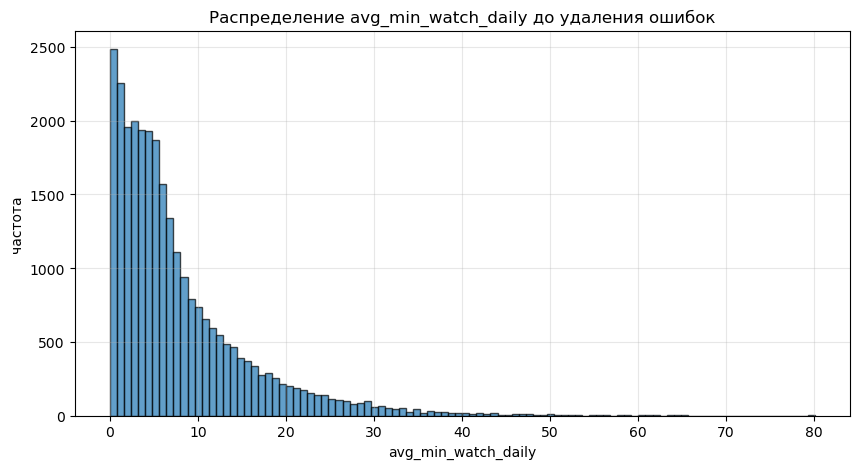

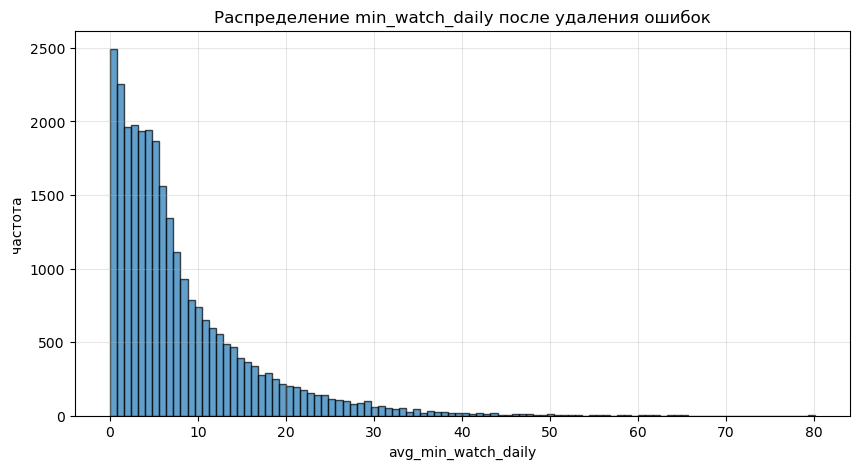

Графики почт идентичные, возможно, такиех записей было очень мало и их просто не видно.
В data 23 записей, от которых мы избавились в data_clean.
Да, данных было очень мало!


In [12]:
# ГИПОТЕЗА №1

# сначала удалим явные ошибки - пользователи, которые заходят в приложение менее одной секунды
mask = data['avg_min_watch_daily'] > 0.01
data_clean = data[mask].copy()

# проверяем распределдение, стало ли оно менее скошенным
plt.figure(figsize=(10, 5))
plt.hist(data['avg_min_watch_daily'], bins=100, alpha=0.7, edgecolor='black')
plt.title('Распределение avg_min_watch_daily до удаления ошибок')
plt.xlabel('avg_min_watch_daily')
plt.ylabel('частота')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(data_clean['avg_min_watch_daily'], bins=100, alpha=0.7, edgecolor='black')
plt.title('Распределение min_watch_daily после удаления ошибок')
plt.xlabel('avg_min_watch_daily')
plt.ylabel('частота')
plt.grid(True, alpha=0.3)
plt.show()

print('Графики почт идентичные, возможно, такиех записей было очень мало и их просто не видно.')
very_low = data['avg_min_watch_daily'] < 0.01
print(f'В data {very_low.sum()} записей, от которых мы избавились в data_clean.')
print('Да, данных было очень мало!')

# Гипотеза 1

Проверим 1 гипотезу - чем больше времени пользователь проводит в приложении, тем меньше вероятность его покупки.

В данном случае мы работаем с независимой непрерывной величиной - avg_min_wath_daily и с зависимой бинарной churn, поэтому подходящая методология для проверки этой гипотезы - тест Манна-Уитни.

Наш вопрос в терминах этой методологии звучит так:

Различается ли X в двух независимых группах Y?

# Hypothesis 1

We are testing the first hypothesis: the more time a user spends in the app, the lower the probability of purchase.

In this case, we are working with an independent continuous variable — avg_min_watch_daily — and a dependent binary variable — churn.
Therefore, the appropriate methodology for testing this hypothesis is the Mann–Whitney U test.

Our research question in terms of this methodology is:

Does X differ between the two independent groups of Y?

In [13]:
# ГИПОТЕЗА №1

# разделяем пользователей на две группы - тех, кто купил, и тех, кто не купил
group_sub = data_clean[data_clean['churn'] == 1]['avg_min_watch_daily']
group_not_sub = data_clean[data_clean['churn'] == 0]['avg_min_watch_daily']
print(f'Купили подписку {len(group_sub)} пользователей;')
print(f'Не купили подписку {len(group_not_sub)} пользователей.')

print()

# используем тест Манна-Уитни, так как этот статистический тест непараметрический - он устойчив к не нормальному распределению
u_stat, p_value = stats.mannwhitneyu(group_sub, group_not_sub, alternative='less')
print(f'p-value: {p_value:.6f}')
print('Гипотеза подтверждается!\nПользователи, которые покупают подписку, действительно меньше времени проводят в приложении!' if p_value < 0.05 else 'Гипотеза не подтверждена!')

Купили подписку 22077 пользователей;
Не купили подписку 5900 пользователей.

p-value: 0.000000
Гипотеза подтверждается!
Пользователи, которые покупают подписку, действительно меньше времени проводят в приложении!


# Гипотеза 2

Проверим 2 гипотезу - пользователи, у которых ios, с большей вероятностью купят подписку (предполагаем, что у них больше денег и они охотнее их тратят).

В данном случае мы работаем с категориальной переменной device и с бинарной churn.

Вопрос с точки зрения терминологии будет звучать так:

Доля покупок различается между категориями X?

Поэтому инструментом выбираем Хи-квадрат.

# Hypothesis 2

We are testing the second hypothesis: iOS users are more likely to purchase a subscription (assuming they have more disposable income and are more willing to spend it).

In this case, we are working with a categorical independent variable — device — and a binary dependent variable — churn.

The research question in statistical terminology is:

Does the purchase rate differ across categories of X?

Therefore, we select Chi‑square test as the appropriate tool.

In [14]:
# ГИПОТЕЗА №2

# строим таблицу сопряженности
table = pd.crosstab(data_clean['device'], data_clean['churn'])
print('Таблица покупок по устройствам:')
print(table)
print()

print('Доля купивших по устройствам:')
pur_rate = table[1] / (table[0] + table[1])
print(pur_rate.sort_values(ascending=False))
print()

# Хи-квадрат тест
chi2, p_value, dof, expected = chi2_contingency(table)
print(f'Хи-квадрат: {chi2:.2f}\np-value: {p_value:.6f}')
print('ios влияет на частоту покупок!' if p_value < 0.05 else 'ios не влияет на частоту покупок...')

# в случае, если нулевая гипотеза не верна, проверям, покупают ли пользователи ios чаще среднего по группам
if p_value < 0.05:
    ios_rate = pur_rate.get('ios', 0)
    other_rate = pur_rate.drop('ios', errors='ignore')
    
    if ios_rate > other_rate.mean():
        print('Пользователи ios покупают чаще среднего!')
    else:
        print('Зависимость есть, но ios пользователи покупают реже среднего!')

Таблица покупок по устройствам:
churn       0      1
device              
android   730   2684
ios       680   2594
smarttv   725   2829
web      3765  13970

Доля купивших по устройствам:
device
smarttv    0.796005
ios        0.792303
web        0.787708
android    0.786175
dtype: float64

Хи-квадрат: 1.60
p-value: 0.658934
ios не влияет на частоту покупок...


# Гипотеза 3

Проверим 3 гипотезу - любимый жанр пользователя не влияет на то, купит он подписку или нет.

В данном случае мы работаем с категориальной переменной favourite_genre и с бинарной churn - поэтому с точки зрения методологии мы опять используем Хи-квадрат для проверки гипотезы (она, кстати, и будет нулевой).

Поехали!

# Hypothesis 3

Let's test the third hypothesis: the user's favorite genre does not affect whether they purchase a subscription.

In this case, we are working with a categorical independent variable — favourite_genre — and a binary dependent variable — churn. Therefore, from a methodological standpoint, we again use the Chi‑square test to test the hypothesis (which, in fact, will be the null hypothesis).

Let's go!

In [15]:
# ГИПОТЕЗА №3

# строим таблицу сопряженности
table = pd.crosstab(data_clean['favourite_genre'], data_clean['churn'])
print('Таблица покупок по любимым жанрам:')
print(table)
print()

print('Доля купивших по любимым жанрам:')
pur_rate = table[1] / (table[0] + table[1])
print(pur_rate.sort_values(ascending=False))
print()

# Хи-квадрат тест
chi2, p_value, dof, expected = chi2_contingency(table)
print(f'Хи-квадрат: {chi2:.2f}\np_value: {p_value:.6f}')
print('Жанр влияет на частоту покупок!' if p_value < 0.05 else 'Жанр не влияет на частоту покупок...')

Таблица покупок по любимым жанрам:
churn               0      1
favourite_genre             
action            736   2871
comedy            905   3373
criminal          636   2413
drama            2721  10152
thriller          902   3268

Доля купивших по любимым жанрам:
favourite_genre
action      0.795952
criminal    0.791407
drama       0.788627
comedy      0.788453
thriller    0.783693
dtype: float64

Хи-квадрат: 1.88
p_value: 0.758581
Жанр не влияет на частоту покупок...


# ВЫВОДЫ ИССЛЕДОВАНИЯ

Я проверил три гипотезы. Вот краткие выводы по каждой:

**Гипотеза 1: Подтверждена.** Пользователи, которые покупают подписку, проводят в приложении меньше времени. Это важно для прогнозирования прибыльности: возможно, более активные пользователи менее склонны к покупке, и модель должна учитывать эту обратную зависимость.
   
**Гипотеза 2: Отвергнута.** Тип устройства (iOS, Android, Web, SmartTV) не влияет на вероятность покупки подписки. Все устройства показывают схожую конверсию (~78-79%). Это контринтуитивно, но означает, что при прогнозировании прибыльности рекламного показа не нужно отдавать предпочтение пользователям определенных устройств.

**Гипотеза 3: Подтверждена.** Любимый жанр пользователя не влияет на вероятность покупки подписки. Все жанры имеют примерно одинаковую конверсию. Следовательно, при прогнозировании прибыльности рекламного показа жанровые предпочтения не являются значимым фактором.

**АНАЛИТИЧЕСКИЕ ВЫВОДЫ ДЛЯ ML-ОТДЕЛА:**

* Для модели, прогнозирующей прибыльность рекламного показа, среднее время просмотра в день является важным признаком, но с обратной зависимостью: чем больше времени пользователь проводит в приложении, тем ниже вероятность покупки подписки.
* Тип устройства и любимый жанр не являются статистически значимыми предикторами покупки подписки в наших данных. Их можно исключить из модели или использовать с осторожностью, так как они не несут дополнительной объясняющей силы.
* Обратите внимание на дисбаланс классов: купивших подписку в ~3.7 раза больше, чем не купивших. Возможно, потребуется балансировка данных или использование соответствующих метрик (F1, Precision-Recall).

Рекомендуется также изучить другие признаки (например, источник перехода, город, количество дней в приложении) и их влияние на целевую переменную.

# RESEARCH FINDINGS

I tested three hypotheses. Here are the brief conclusions for each:

**Hypothesis 1: Confirmed.** Users who purchase a subscription spend less time in the application. This is important for profitability forecasting: it suggests that more active users may be less inclined to purchase, and the model should account for this inverse relationship.

**Hypothesis 2: Rejected.** The type of device (iOS, Android, Web, SmartTV) does not affect the likelihood of purchasing a subscription. All devices show similar conversion rates (~78–79%). This is counterintuitive but means that when forecasting ad profitability, there is no need to prioritize users of specific devices.

**Hypothesis 3: Confirmed.** The user’s favorite genre does not influence the probability of purchasing a subscription. All genres have approximately the same conversion rate. Therefore, when predicting ad profitability, genre preferences are not a significant factor.

**ANALYTICAL INSIGHTS FOR THE ML TEAM:**

For a model predicting the profitability of ad impressions:

* Daily average watch time is an important feature, but with an inverse relationship: the more time a user spends in the app, the lower the probability of subscription purchase.

* Device type and favorite genre are not statistically significant predictors of subscription purchase in our data. They can be excluded from the model or used with caution, as they do not add explanatory power.

* Note the class imbalance: subscribers outnumber non-subscribers by ~3.7 times. Data balancing or appropriate metrics (F1, Precision-Recall) may be required.

It is also recommended to investigate other features (e.g., traffic source, city, number of days in the app) and their impact on the target variable.